In [1]:
from pathlib import Path
import sys
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
ROOT = next(
    (p for p in [Path.cwd(), *Path.cwd().parents] if (p / "project_paths.py").exists()),
    None
)
if ROOT is None:
    raise RuntimeError("Racine du projet introuvable (project_paths.py non trouvé).")

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))



In [3]:
from project_paths import PROCESSED_DATA_DIR
path_of_df_nextBuy = PROCESSED_DATA_DIR / "nextbuy.pkl.gz"
df_nextBuy = df = pd.read_pickle(path_of_df_nextBuy , compression="gzip")

In [6]:
#Prepare Data (The bestseller department)
sells_by_department = (
    df_nextBuy
    .groupby("department_id")["order_id"]
    .nunique()
    .reset_index(name= "num_orders")
)

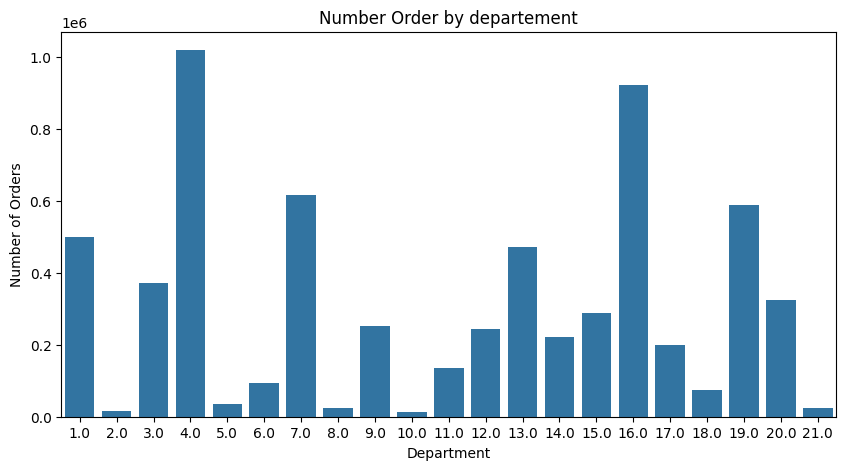

In [8]:
#Create Graphic (the bestseller department)

plt.figure(figsize=(10,5))

sns.barplot(
    data = sells_by_department,
    x = "department_id",
    y = "num_orders",
)


plt.title("Number Order by departement")
plt.xlabel("Department")
plt.ylabel("Number of Orders")


plt.show()

Observation:

Les produits bestsellers sont d'abords les "produce" numéros 4, puis les "dairy eggs" numéros 16 et en 3 eme position presque exequaux les "beverages" et les "snacks" respectivement numéros 7 et 19.
Maintenant que l'on a identifier les departement bestseller on peut maintenant chercher à connaitre les rayon bestseller de ces departement

Le rayon Bestseller de produce

In [9]:
#Prepare data for bestseller aisles of produce

df_produce = df_nextBuy[df_nextBuy["department_id"] == 4]

sells_of_the_aisles_produce = (
    df_produce
    .groupby("aisle_id")["order_id"]
    .nunique()
    .reset_index(name="num_orders")
)


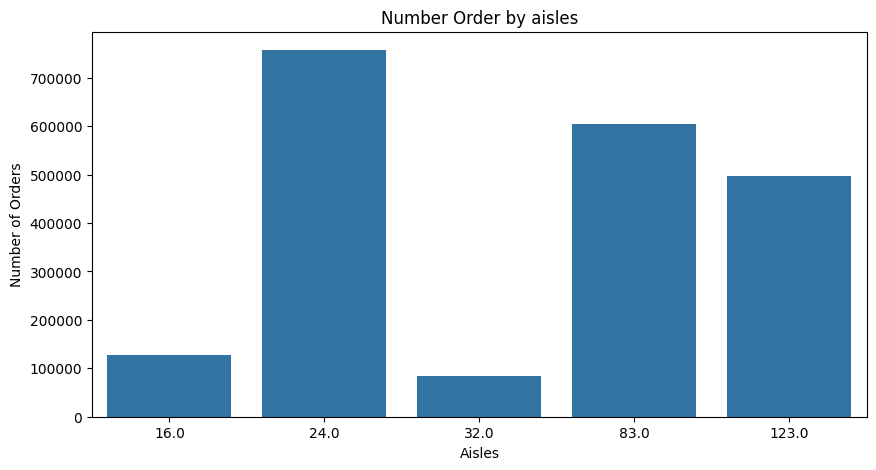

In [10]:
plt.figure(figsize=(10,5))

sns.barplot(
    data = sells_of_the_aisles_produce,
    x = "aisle_id",
    y = "num_orders",
)


plt.title("Number Order by aisles")
plt.xlabel("Aisles")
plt.ylabel("Number of Orders")


plt.show()

Les rayons  bestseller de produce dont tout d'abord "fresh fruits" le 24 puis en deuxième position 83 qui sont les "fresh vegetable" et enfin le 123 qui sont les packages de fruit et légumes.
On peut encore aller plus dans le détailler et voir quels fruits sont les plus achetés.

Voyons maintenant voir en détaille les fresh fruits pour identifier les bestsellers dans cette partie là

In [ ]:
#Prepare data for bestsellers fruits

df_fresh_fruits = df_nextBuy[df_nextBuy["aisle_id"] == 24]

sells_of_the_fresh_fruits = (
    df_fresh_fruits
    .groupby("product_id")["order_id"]
    .nunique()
    .reset_index(name="num_orders")
)

In [12]:
#remove num_orders qui sont moins de 75000
product_bestsellers = sells_of_the_fresh_fruits[
    sells_of_the_fresh_fruits["num_orders"] >= 75000
]

In [13]:
product_bestsellers = product_bestsellers.merge(
    df_nextBuy[["product_id", "product_name"]],
    on="product_id",
    how="left"
)
product_bestsellers = product_bestsellers.drop_duplicates()

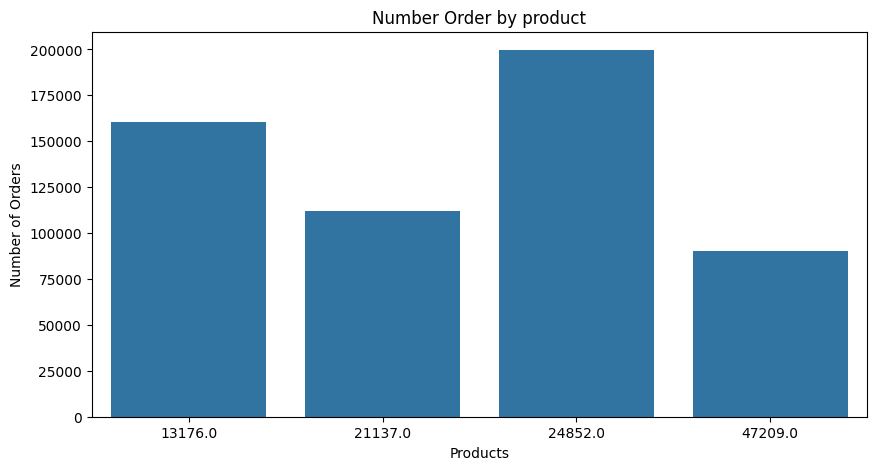

In [14]:
#Graphic of bestseller aisles of produce
plt.figure(figsize=(10,5))

sns.barplot(
    data = product_bestsellers,
    x = "product_id",
    y = "num_orders",
)


plt.title("Number Order by product")
plt.xlabel("Products")
plt.ylabel("Number of Orders")


plt.show()

13176 = Organic Bananas             21137 = Organic Strawberries


24852 = Banana           47209  = Organic Hass Avocado

Observation:

On observe que les bananes est le produit le plus commander qu'il soit bio ou non il fait partie du top 4. Par ailleurs 3 des élément du top 4 sont bio.

Déductions:

Cela  nous indique une préocupation du consommateur pour l'environemment et ça santé quitte a payer plus chers.(Nous n'avons pas le prix des produit mais nous suppsons que les produit bio sont plus cher, notamment car les banane non bio sont plus acheter surement dû a un prix avantageux)

Insight:

Proposer des produit qui sont bio, healthy ou éco-friendly et un avanatage manifeste, en particulier chez les clients qui consomme déjà ces produits